###This notebook reproduces and critically evaluates the methodology of Subrata Maji's UNSW-NB15 IDS tutorial.

#Downloading Necessary Files

In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np
import seaborn as sns
import sklearn

In [2]:
!git clone https://github.com/SubrataMaji/IDS-UNSW-NB15.git reference_IDS_UNSW_NB15
!find reference_IDS_UNSW_NB15 -maxdepth 2 -type f

fatal: destination path 'reference_IDS_UNSW_NB15' already exists and is not an empty directory.
reference_IDS_UNSW_NB15/2. EDA/Exploratory Data Analysis.ipynb
reference_IDS_UNSW_NB15/5. Predict data/Prediction of Raw Data.ipynb
reference_IDS_UNSW_NB15/README.md
reference_IDS_UNSW_NB15/.gitattributes
reference_IDS_UNSW_NB15/.git/index
reference_IDS_UNSW_NB15/.git/config
reference_IDS_UNSW_NB15/.git/HEAD
reference_IDS_UNSW_NB15/.git/description
reference_IDS_UNSW_NB15/.git/packed-refs
reference_IDS_UNSW_NB15/4. ML Models/ML Models and Results.ipynb
reference_IDS_UNSW_NB15/1. Dataset/About Dataset and It's Cleaning.ipynb
reference_IDS_UNSW_NB15/3. Preprocessing/Feature Engineering and Data Preparation.ipynb


In [3]:
!pip install -q kaggle xgboost

In [4]:
from google.colab import files

uploaded = files.upload()#uploading kaggle key in a json file

Saving kaggle.json to kaggle (2).json


In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!rm -rf data/raw
!mkdir -p data/raw/full_csv

!kaggle datasets download -d mrwellsdavid/unsw-nb15 -p data/raw/full_csv --unzip

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
100% 149M/149M [00:01<00:00, 129MB/s]



In [7]:
!find data/raw/full_csv -maxdepth 4 -type f | head -100

data/raw/full_csv/NUSW-NB15_features.csv
data/raw/full_csv/UNSW_NB15_testing-set.csv
data/raw/full_csv/UNSW-NB15_LIST_EVENTS.csv
data/raw/full_csv/UNSW_NB15_training-set.csv
data/raw/full_csv/UNSW-NB15_4.csv
data/raw/full_csv/UNSW-NB15_3.csv
data/raw/full_csv/UNSW-NB15_2.csv
data/raw/full_csv/UNSW-NB15_1.csv


In [8]:
from pathlib import Path
import re

raw_dir = Path("data/raw/full_csv")

all_files = sorted([p for p in raw_dir.rglob("*") if p.is_file()])

print("All files found:")
for p in all_files[:100]:
    print(p)

csv_files = sorted(raw_dir.rglob("*.csv"))

print("\nCSV files found:")
for p in csv_files:
    print(p)

All files found:
data/raw/full_csv/NUSW-NB15_features.csv
data/raw/full_csv/UNSW-NB15_1.csv
data/raw/full_csv/UNSW-NB15_2.csv
data/raw/full_csv/UNSW-NB15_3.csv
data/raw/full_csv/UNSW-NB15_4.csv
data/raw/full_csv/UNSW-NB15_LIST_EVENTS.csv
data/raw/full_csv/UNSW_NB15_testing-set.csv
data/raw/full_csv/UNSW_NB15_training-set.csv

CSV files found:
data/raw/full_csv/NUSW-NB15_features.csv
data/raw/full_csv/UNSW-NB15_1.csv
data/raw/full_csv/UNSW-NB15_2.csv
data/raw/full_csv/UNSW-NB15_3.csv
data/raw/full_csv/UNSW-NB15_4.csv
data/raw/full_csv/UNSW-NB15_LIST_EVENTS.csv
data/raw/full_csv/UNSW_NB15_testing-set.csv
data/raw/full_csv/UNSW_NB15_training-set.csv


In [9]:
from pathlib import Path
import pandas as pd
import re

raw_dir = Path("data/raw/full_csv")
csv_files = sorted(raw_dir.rglob("*.csv"))

def normalize_name(path):
    return path.name.lower().replace("-", "").replace("_", "")

data_files = []

for i in range(1, 5):
    matches = [
        p for p in csv_files
        if f"unswnb15{i}.csv" in normalize_name(p)
    ]

    if not matches:
        raise FileNotFoundError(f"Could not find UNSW-NB15_{i}.csv")

    data_files.append(matches[0])

print("Using data files:")
for p in data_files:
    print(p)

feature_candidates = [
    p for p in csv_files
    if "features" in p.name.lower()
]

if not feature_candidates:
    raise FileNotFoundError("Could not find UNSW-NB15_features.csv or NUSW-NB15_features.csv")

features_path = feature_candidates[0]
print("\nUsing features file:")
print(features_path)

Using data files:
data/raw/full_csv/UNSW-NB15_1.csv
data/raw/full_csv/UNSW-NB15_2.csv
data/raw/full_csv/UNSW-NB15_3.csv
data/raw/full_csv/UNSW-NB15_4.csv

Using features file:
data/raw/full_csv/NUSW-NB15_features.csv


In [10]:
dfs = []

for path in data_files:
    print("Loading:", path)
    df_part = pd.read_csv(path, header=None, low_memory=False)
    print("Shape:", df_part.shape)
    dfs.append(df_part)

all_data = pd.concat(dfs, ignore_index=True)

print("\nCombined shape before column names:", all_data.shape)

features_df = pd.read_csv(features_path, encoding="ISO-8859-1")

display(features_df.head())
print(features_df.columns)

Loading: data/raw/full_csv/UNSW-NB15_1.csv
Shape: (700001, 49)
Loading: data/raw/full_csv/UNSW-NB15_2.csv
Shape: (700001, 49)
Loading: data/raw/full_csv/UNSW-NB15_3.csv
Shape: (700001, 49)
Loading: data/raw/full_csv/UNSW-NB15_4.csv
Shape: (440044, 49)

Combined shape before column names: (2540047, 49)


,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol


Index(['No.', 'Name', 'Type ', 'Description'], dtype='object')


In [11]:
# Find the column that contains feature names
name_col_candidates = [
    col for col in features_df.columns
    if col.strip().lower() == "name"
]

if not name_col_candidates:
    raise ValueError("Could not find a 'Name' column in the features file.")

name_col = name_col_candidates[0]

column_names = (
    features_df[name_col]
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
    .str.lower()
    .tolist()
)

print("Number of column names:", len(column_names))
print("Number of columns in all_data:", all_data.shape[1])

if len(column_names) != all_data.shape[1]:
    raise ValueError(
        f"Mismatch: features file has {len(column_names)} names, "
        f"but data has {all_data.shape[1]} columns."
    )

all_data.columns = column_names

print("Final shape:", all_data.shape)
display(all_data.head())

Number of column names: 49
Number of columns in all_data: 49
Final shape: (2540047, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0


In [12]:
# Clean string/categorical columns
for col in all_data.select_dtypes(include=["object"]).columns:
    all_data[col] = all_data[col].astype(str).str.strip()

# attack_cat sometimes has missing/blank values for normal traffic
if "attack_cat" in all_data.columns:
    all_data["attack_cat"] = all_data["attack_cat"].replace(["nan", "NaN", ""], "Normal")

print(all_data.shape)
print(all_data.dtypes.value_counts())

if "label" in all_data.columns:
    print(all_data["label"].value_counts())

if "attack_cat" in all_data.columns:
    print(all_data["attack_cat"].value_counts())

(2540047, 49)
int64      28
float64    12
object      9
Name: count, dtype: int64
label
0    2218764
1     321283
Name: count, dtype: int64
attack_cat
Normal            2218764
Generic            215481
Exploits            44525
Fuzzers             24246
DoS                 16353
Reconnaissance      13987
Analysis             2677
Backdoor             1795
Shellcode            1511
Backdoors             534
Worms                 174
Name: count, dtype: int64


In [13]:
from pathlib import Path

processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

all_data.to_parquet("data/processed/unsw_nb15_full_all.parquet", index=False)

print("Saved:")
!ls -lh data/processed

Saved:
total 182M
-rw-r--r-- 1 root root 182M Jul 15 12:55 unsw_nb15_full_all.parquet


In [14]:
import pandas as pd

all_data = pd.read_parquet("data/processed/unsw_nb15_full_all.parquet")

print(all_data.shape)
display(all_data.head())

(2540047, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,Normal,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,Normal,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,Normal,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,Normal,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,Normal,0


## Duplicate Row Analysis

In [15]:
import pandas as pd
import numpy as np
from pandas.util import hash_pandas_object

print("Original all_data shape:", all_data.shape)

# Count exact duplicated rows in the full concatenated dataset
num_duplicated_rows = all_data.duplicated().sum()
num_unique_rows = len(all_data.drop_duplicates())

print("Number of duplicated rows:", num_duplicated_rows)
print("Number of unique rows:", num_unique_rows)
print("Duplicate percentage:", num_duplicated_rows / len(all_data) * 100)

Original all_data shape: (2540047, 49)
Number of duplicated rows: 480633
Number of unique rows: 2059414
Duplicate percentage: 18.92220891975621


In [16]:
from sklearn.model_selection import train_test_split

target_col = "label"

# Make sure label is numeric
all_data[target_col] = all_data[target_col].astype(int)

train_df, test_df = train_test_split(
    all_data,
    test_size=0.2,
    stratify=all_data[target_col],
    random_state=42
)

# Reset indices for cleaner notebook output
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("train_df:", train_df.shape)
print("test_df:", test_df.shape)

train_df: (2032037, 49)
test_df: (508010, 49)


In [17]:
# Compute row hashes for exact duplicate-overlap analysis
train_hashes = hash_pandas_object(train_df, index=False)
test_hashes = hash_pandas_object(test_df, index=False)

train_hash_set = set(train_hashes)

test_rows_overlapping_train = test_hashes.isin(train_hash_set).sum()
test_overlap_percentage = test_rows_overlapping_train / len(test_df) * 100

print("Test rows with exact duplicate also present in train:", test_rows_overlapping_train)
print("Percentage of test rows overlapping train:", test_overlap_percentage)

Test rows with exact duplicate also present in train: 110514
Percentage of test rows overlapping train: 21.754296175272138


### Duplicate Leakage Observation

After concatenating the four raw UNSW-NB15 CSV files and performing a random train-test split, I checked for exact duplicate rows. This is important because if identical records appear in both the training and test sets, the test performance may be overly optimistic. In that case, the model may partly be recognizing repeated records rather than generalizing to genuinely unseen traffic.

## Deduplicated Dataset Experiment

In [18]:
# Remove exact duplicate rows before splitting
dedup_data = all_data.drop_duplicates().reset_index(drop=True)

print("Original dataset shape:", all_data.shape)
print("Deduplicated dataset shape:", dedup_data.shape)
print("Rows removed:", len(all_data) - len(dedup_data))
print("Removed percentage:", (len(all_data) - len(dedup_data)) / len(all_data) * 100)

Original dataset shape: (2540047, 49)
Deduplicated dataset shape: (2059414, 49)
Rows removed: 480633
Removed percentage: 18.92220891975621


In [19]:
from sklearn.model_selection import train_test_split

target_col = "label"

dedup_data[target_col] = dedup_data[target_col].astype(int)

train_df_dedup, test_df_dedup = train_test_split(
    dedup_data,
    test_size=0.2,
    stratify=dedup_data[target_col],
    random_state=42
)

train_df_dedup = train_df_dedup.reset_index(drop=True)
test_df_dedup = test_df_dedup.reset_index(drop=True)

print("Deduplicated train shape:", train_df_dedup.shape)
print("Deduplicated test shape:", test_df_dedup.shape)

print("\nDeduplicated train label distribution:")
print(train_df_dedup[target_col].value_counts(normalize=True))

print("\nDeduplicated test label distribution:")
print(test_df_dedup[target_col].value_counts(normalize=True))

Deduplicated train shape: (1647531, 49)
Deduplicated test shape: (411883, 49)

Deduplicated train label distribution:
label
0    0.951616
1    0.048384
Name: proportion, dtype: float64

Deduplicated test label distribution:
label
0    0.951615
1    0.048385
Name: proportion, dtype: float64


In [20]:
train_hashes_dedup = hash_pandas_object(train_df_dedup, index=False)
test_hashes_dedup = hash_pandas_object(test_df_dedup, index=False)

train_hash_set_dedup = set(train_hashes_dedup)

test_rows_overlapping_train_dedup = test_hashes_dedup.isin(train_hash_set_dedup).sum()

print("Deduplicated test rows with exact duplicate in train:", test_rows_overlapping_train_dedup)

Deduplicated test rows with exact duplicate in train: 0


#EDA

##Setup

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

##Basic Dataset Overview

In [22]:
print("Train shape:", train_df_dedup.shape)
print("Test shape:", test_df_dedup.shape)

display(train_df.head())
display(train_df.tail())

Train shape: (1647531, 49)
Test shape: (411883, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
0,59.166.0.7,64065,149.171.126.7,37113,tcp,FIN,0.037659,4862,80366,31,29,7,36,-,1.020739e+06,1.687395e+07,84,86,255,255,2435004582,285738032,58,934,0,0,23.466556,22.566234,1421967251,1421967251,0.449434,0.435541,0.000800,0.000628,0.000172,0,0,0.0,0.0,0,2,10,1,2,1,1,1,Normal,0
1,59.166.0.2,8673,149.171.126.7,80,tcp,FIN,6.547769,18994,1087890,31,29,2,370,http,2.314193e+04,1.327392e+06,356,746,255,255,2826967915,682637128,53,1458,1,524288,3092.244562,2121.155989,1424230733,1424230740,18.495588,8.788196,0.000680,0.000560,0.000120,0,0,1.0,NaN,,1,1,3,1,1,1,1,Normal,0
2,149.171.126.18,47439,175.45.176.1,53,udp,INT,0.000004,264,0,60,0,0,0,dns,2.640000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1421931757,1421931757,0.004000,0.000000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,6,6,3,3,3,3,3,Normal,0
3,59.166.0.9,58846,149.171.126.4,80,tcp,FIN,1.237505,1684,10168,31,29,3,5,http,1.011067e+04,6.208621e+04,14,18,255,255,1071764348,3288990154,120,565,1,3924,8919.445525,7810.571697,1421957149,1421957150,95.164536,72.757941,0.000755,0.000617,0.000138,0,0,1.0,0.0,0,2,3,2,4,2,1,1,Normal,0
4,175.45.176.0,0,149.171.126.17,0,rsvp,INT,0.000007,200,0,254,0,0,0,-,1.142857e+08,0.000000e+00,2,0,0,0,0,0,100,0,0,0,0.000000,0.000000,1424251654,1424251654,0.007000,0.000000,0.000000,0.000000,0.000000,0,2,NaN,NaN,,4,4,2,2,2,2,4,Reconnaissance,1


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
2032032,59.166.0.0,44654,149.171.126.3,25,tcp,FIN,0.068799,37460,3380,31,29,18,8,smtp,4272155.500,3.837265e+05,52,42,255,255,1007197264,3154176303,720,80,0,0,100.046133,4.966537,1421950130,1421950130,1.338804,1.665707,0.000724,0.000502,0.000222,0,0,0.0,0.0,0,1,1,2,3,1,1,2,Normal,0
2032033,59.166.0.0,47430,149.171.126.9,54212,udp,CON,0.001715,536,304,31,29,0,0,-,1875218.625,1.063557e+06,4,4,0,0,0,0,134,76,0,0,0.629325,0.295808,1424230226,1424230226,0.448000,0.214667,0.000000,0.000000,0.000000,0,0,NaN,NaN,,6,3,6,3,1,1,3,Normal,0
2032034,59.166.0.9,19285,149.171.126.6,53,udp,CON,0.001024,132,164,31,29,0,0,dns,515625.000,6.406250e+05,2,2,0,0,0,0,66,82,0,0,0.000000,0.000000,1424259134,1424259134,0.008000,0.008000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,2,1,1,2,1,1,1,Normal,0
2032035,59.166.0.0,49961,149.171.126.9,58350,tcp,FIN,0.010832,2126,12722,31,29,7,10,-,1521418.125,9.135155e+06,32,36,255,255,550077254,2699895291,66,353,0,0,24.677828,21.902929,1421942552,1421942552,0.338129,0.303882,0.000970,0.000493,0.000477,0,0,0.0,0.0,0,5,10,6,3,1,1,1,Normal,0
2032036,59.166.0.7,18484,149.171.126.7,53,udp,CON,0.001073,146,178,31,29,0,0,dns,544268.375,6.635601e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421941474,1421941474,0.004000,0.008000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,1,3,10,1,1,1,1,Normal,0


In [23]:
print("Columns:")
print(train_df_dedup.columns.tolist())

print("\nData types:")
display(train_df_dedup.dtypes.value_counts())

display(train_df.dtypes)

Columns:
['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label']

Data types:


,count
int64,28
float64,12
object,9


,0
srcip,object
sport,object
dstip,object
dsport,object
proto,object
state,object
dur,float64
sbytes,int64
dbytes,int64
sttl,int64


##Check index and duplicated rows

In [24]:
print("Train index name:", train_df.index.name)
print("Test index name:", test_df.index.name)

print("Train index unique?", train_df.index.is_unique)
print("Test index unique?", test_df.index.is_unique)

print("Duplicated rows in train:", train_df.duplicated().sum())
print("Duplicated rows in test:", test_df.duplicated().sum())

Train index name: None
Test index name: None
Train index unique? True
Test index unique? True
Duplicated rows in train: 368419
Duplicated rows in test: 61098


##Missing Values

In [25]:
missing_train = train_df_dedup.isna().sum().sort_values(ascending=False)
missing_test = test_df_dedup.isna().sum().sort_values(ascending=False)

print("Top missing values in train:")
display(missing_train[missing_train > 0])

print("Top missing values in test:")
display(missing_test[missing_test > 0])

Top missing values in train:


,0
is_ftp_login,811140
ct_flw_http_mthd,747029


Top missing values in test:


,0
is_ftp_login,203025
ct_flw_http_mthd,186574


In [26]:
train_df_dedup['is_ftp_login'] = train_df_dedup['is_ftp_login'].fillna(0)
test_df_dedup['is_ftp_login'] = test_df_dedup['is_ftp_login'].fillna(0)
train_df_dedup['ct_flw_http_mthd'] = train_df_dedup['ct_flw_http_mthd'].fillna(0)
test_df_dedup['ct_flw_http_mthd'] = test_df_dedup['ct_flw_http_mthd'].fillna(0)
print()

This way of handling the missing values was taken from the blog.

##Single-value / constant features

In [27]:
unique_counts = train_df_dedup.nunique().sort_values()

display(unique_counts.head(20))

,0
label,2
is_sm_ips_ports,2
is_ftp_login,4
ct_state_ttl,7
ct_ftp_cmd,9
dttl,11
attack_cat,11
sttl,13
service,13
trans_depth,13


In [28]:
constant_cols = unique_counts[unique_counts <= 1].index.tolist()

print("Constant columns:", constant_cols)
print("Number of constant columns:", len(constant_cols))

Constant columns: []
Number of constant columns: 0


##Target distribution / class imbalance

In [29]:
print("Train label counts:")
display(train_df_dedup["label"].value_counts())

print("Train label proportions:")
display(train_df_dedup["label"].value_counts(normalize=True))

print("Test label counts:")
display(test_df_dedup["label"].value_counts())

print("Test label proportions:")
display(test_df_dedup["label"].value_counts(normalize=True))

Train label counts:


,count
label,
0,1567817
1,79714


Train label proportions:


,proportion
label,
0,0.951616
1,0.048384


Test label counts:


,count
label,
0,391954
1,19929


Test label proportions:


,proportion
label,
0,0.951615
1,0.048385


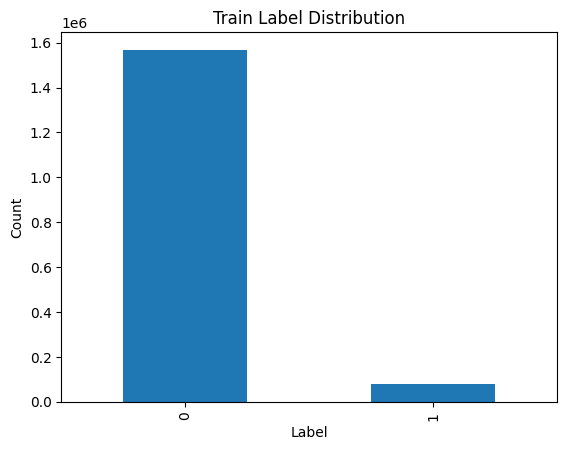

In [30]:
train_df_dedup["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Train Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

As we can see, the majority of the traffic in the dataset is normal traffic and the attack traffic is the minority. It is also close to the numbers we have learned about in class (90-10 split).

##Attack category distribution

In [31]:
print("Attack categories in train:")
display(train_df_dedup["attack_cat"].value_counts())

print("Attack category proportions in train:")
display(train_df_dedup["attack_cat"].value_counts(normalize=True))

Attack categories in train:


,count
attack_cat,
Normal,1567817
Exploits,22113
Generic,20260
Fuzzers,17443
Reconnaissance,10739
DoS,4551
Analysis,1729
Backdoor,1313
Shellcode,1201


Attack category proportions in train:


,proportion
attack_cat,
Normal,0.951616
Exploits,0.013422
Generic,0.012297
Fuzzers,0.010587
Reconnaissance,0.006518
DoS,0.002762
Analysis,0.001049
Backdoor,0.000797
Shellcode,0.000729


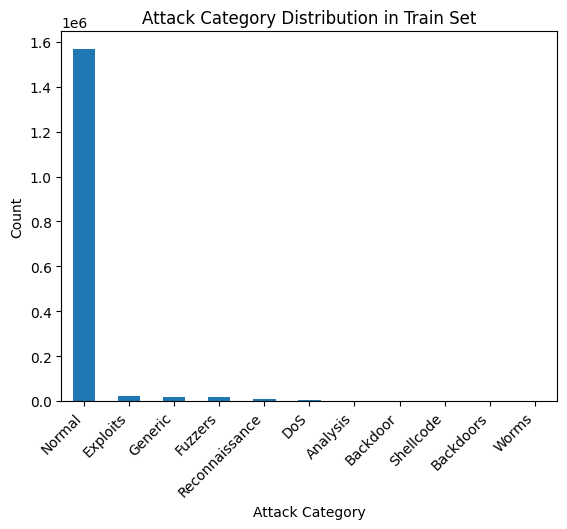

In [32]:
train_df_dedup["attack_cat"].value_counts().plot(kind="bar")
plt.title("Attack Category Distribution in Train Set")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

##Separate numeric and categorical columns

In [33]:
categorical_cols = train_df_dedup.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = train_df_dedup.select_dtypes(include=["int8","int16","int64", "float64", "int32", "float32"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

print("Number of categorical columns:", len(categorical_cols))
print("Number of numeric columns:", len(numeric_cols))

Categorical columns: ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'service', 'ct_ftp_cmd', 'attack_cat']
Numeric columns: ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'label']
Number of categorical columns: 9
Number of numeric columns: 40


##Categorical feature distributions

In [34]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    display(train_df_dedup[col].value_counts().head(20))


Column: srcip


,count
srcip,
59.166.0.4,154250
59.166.0.5,153798
59.166.0.2,153613
59.166.0.0,153448
59.166.0.1,153428
59.166.0.3,152613
59.166.0.9,147762
59.166.0.8,147505
59.166.0.6,147309



Column: sport


,count
sport,
0,17582
1043,16054
47439,15919
2048,312
80,304
5060,193
53,188
6881,161
5190,132



Column: dstip


...

,count
service,
-,935795
dns,309383
http,162518
ftp-data,99973
smtp,64807
ssh,37519
ftp,35998
pop3,1196
ssl,115



Column: ct_ftp_cmd


,count
ct_ftp_cmd,
,811140
0,804630
1,31058
2,208
4,198
3,147
5,76
6,71
8,3



Column: attack_cat


,count
attack_cat,
Normal,1567817
Exploits,22113
Generic,20260
Fuzzers,17443
Reconnaissance,10739
DoS,4551
Analysis,1729
Backdoor,1313
Shellcode,1201


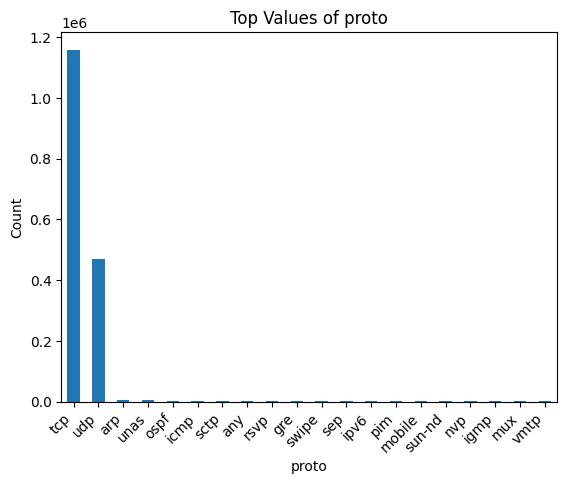

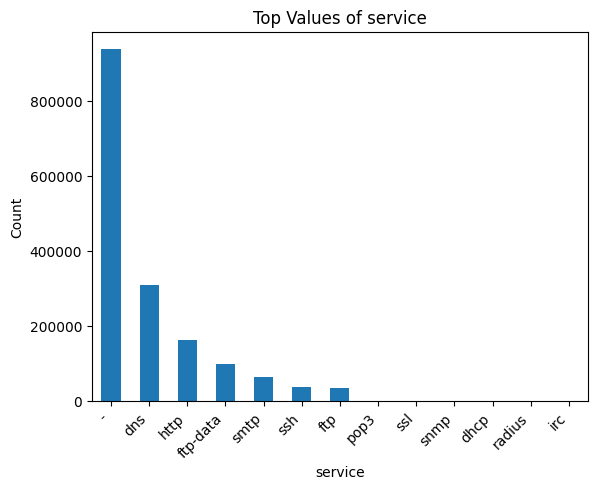

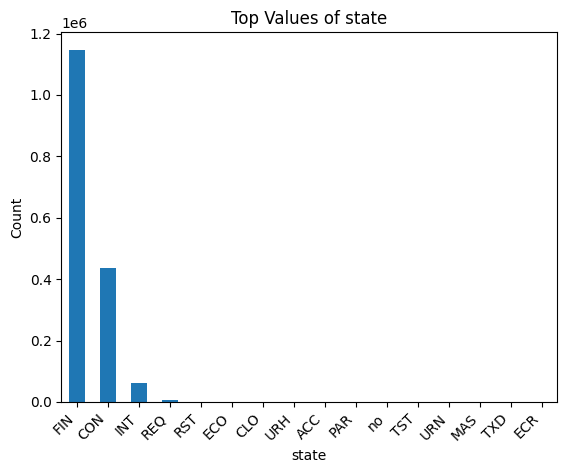

In [35]:
for col in ["proto", "service", "state"]:
    if col in train_df_dedup.columns:
        train_df_dedup[col].value_counts().head(20).plot(kind="bar")
        plt.title(f"Top Values of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.show()

##Numeric feature distributions

In [36]:
numeric_features_for_plots = [
    col for col in numeric_cols
    if col not in ["id", "label"]
]

print(numeric_features_for_plots[:20])

['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit']


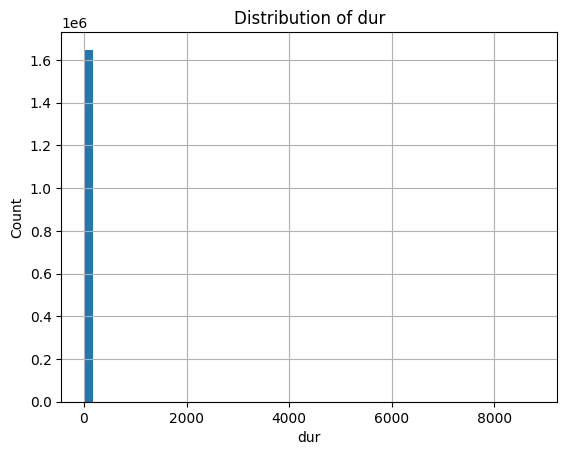

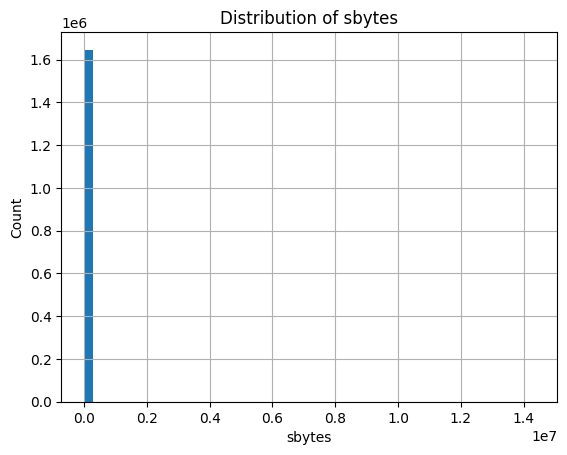

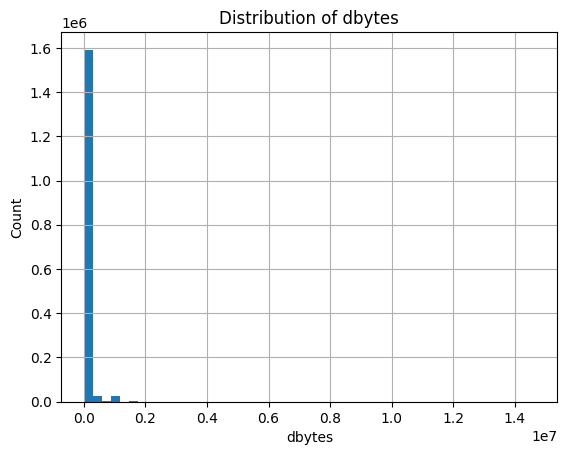

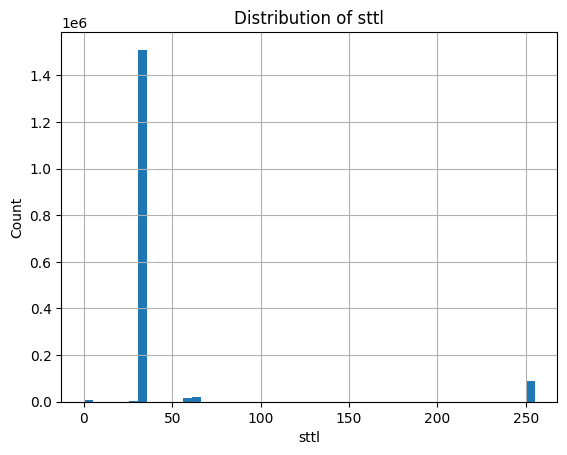

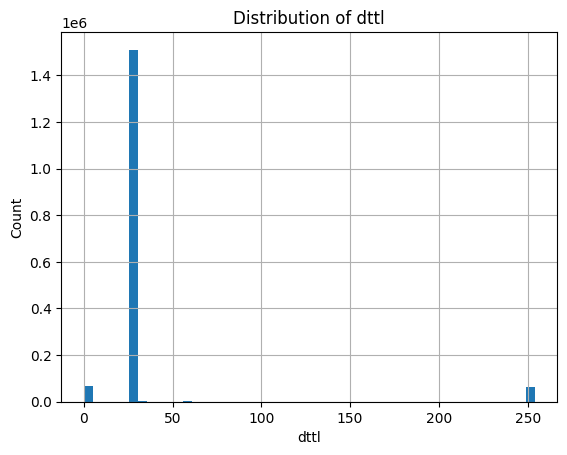

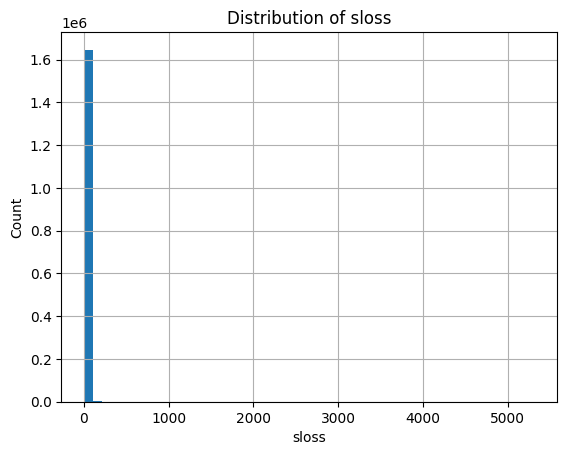

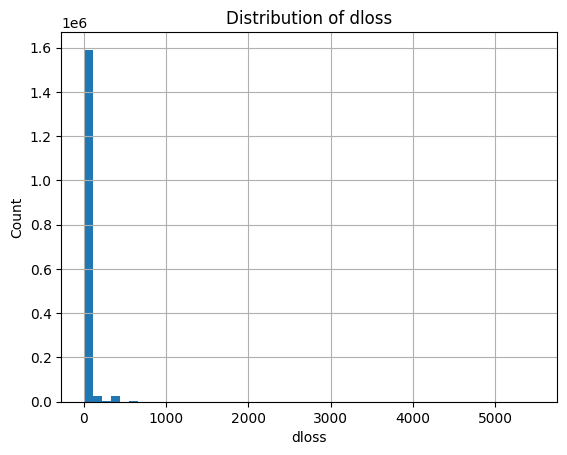

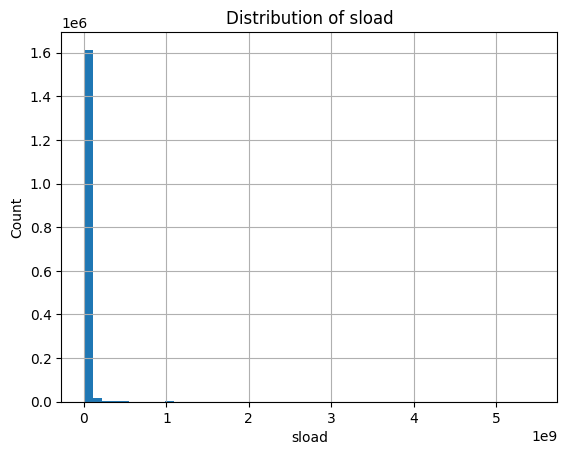

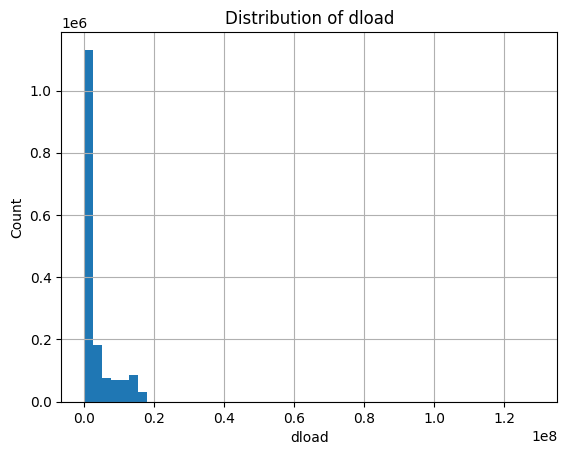

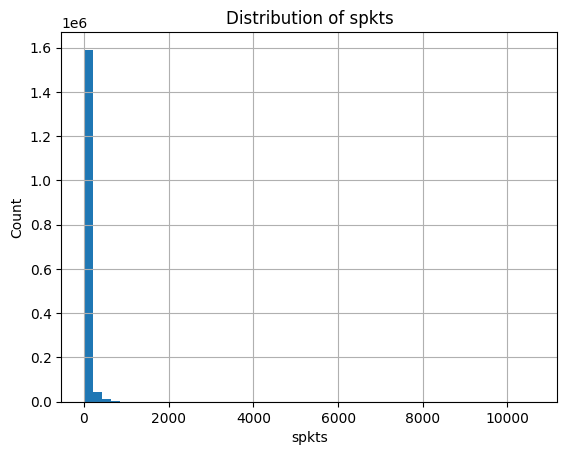

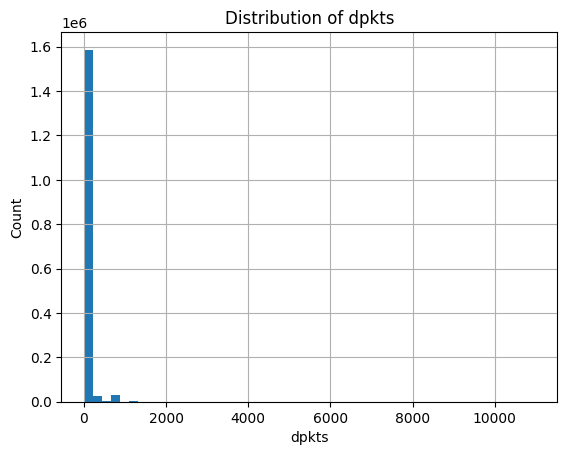

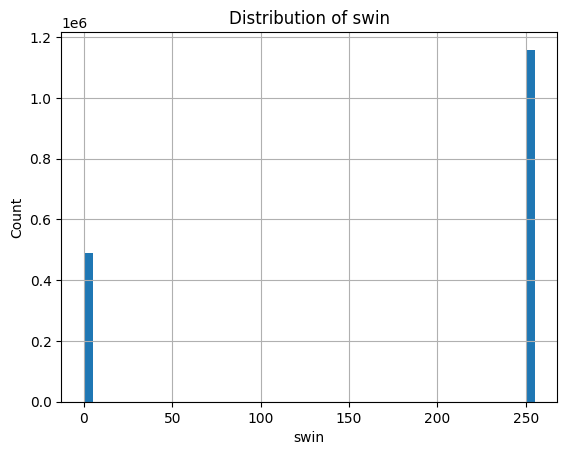

In [37]:
for col in numeric_features_for_plots[:12]:
    train_df_dedup[col].hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

##Outlier Analysis

In [38]:
display(train_df_dedup[numeric_features_for_plots].describe().T)

,count,mean,std,min,25%,50%,75%,max
dur,1647531.0,6.492320e-01,1.016908e+01,0.000000e+00,3.615000e-03,2.640900e-02,3.334305e-01,8.786638e+03
sbytes,1647531.0,5.082009e+03,6.212501e+04,0.000000e+00,4.240000e+02,1.684000e+03,3.728000e+03,1.435577e+07
dbytes,1647531.0,4.188585e+04,1.694305e+05,0.000000e+00,3.040000e+02,3.080000e+03,1.991800e+04,1.465555e+07
sttl,1647531.0,4.358919e+01,5.050986e+01,0.000000e+00,3.100000e+01,3.100000e+01,3.100000e+01,2.550000e+02
dttl,1647531.0,3.650676e+01,4.371772e+01,0.000000e+00,2.900000e+01,2.900000e+01,2.900000e+01,2.540000e+02
sloss,1647531.0,6.107740e+00,2.458855e+01,0.000000e+00,0.000000e+00,4.000000e+00,7.000000e+00,5.319000e+03
dloss,1647531.0,1.891603e+01,5.936514e+01,0.000000e+00,0.000000e+00,5.000000e+00,1.500000e+01,5.484000e+03
sload,1647531.0,9.053297e+06,7.301178e+07,0.000000e+00,8.089428e+04,5.407408e+05,1.095871e+06,5.468000e+09
dload,1647531.0,2.955013e+06,4.480519e+06,0.000000e+00,7.632209e+04,6.693244e+05,3.836296e+06,1.287619e+08
spkts,1647531.0,3.862382e+01,8.048273e+01,0.000000e+00,4.000000e+00,1.600000e+01,4.800000e+01,1.064600e+04


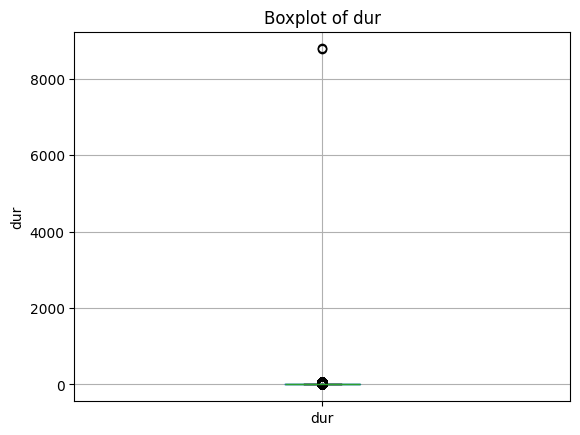

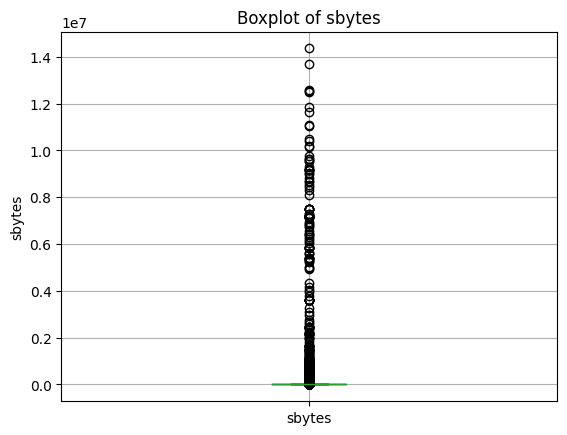

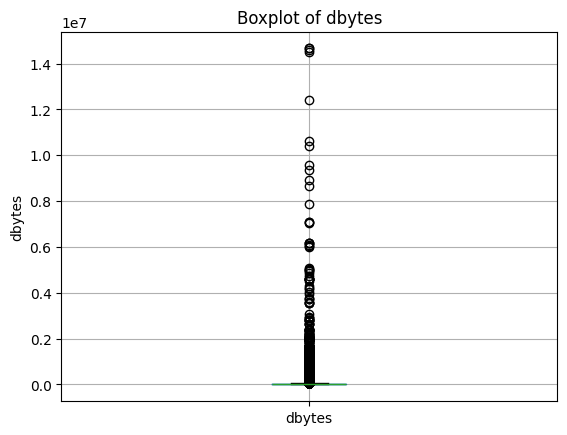

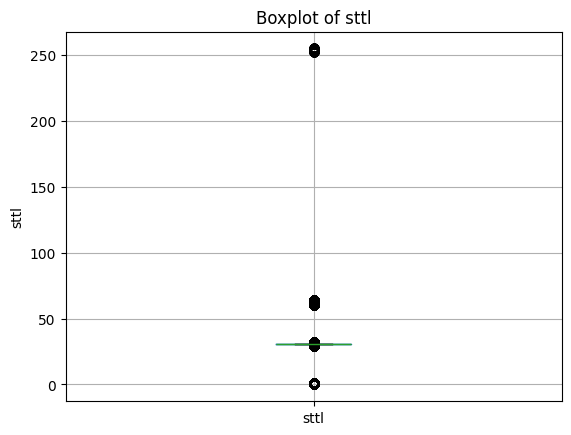

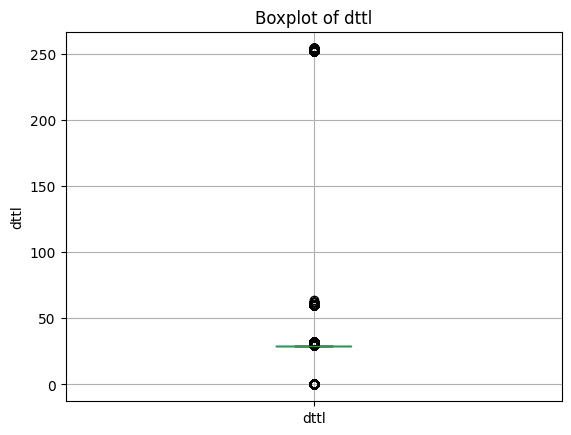

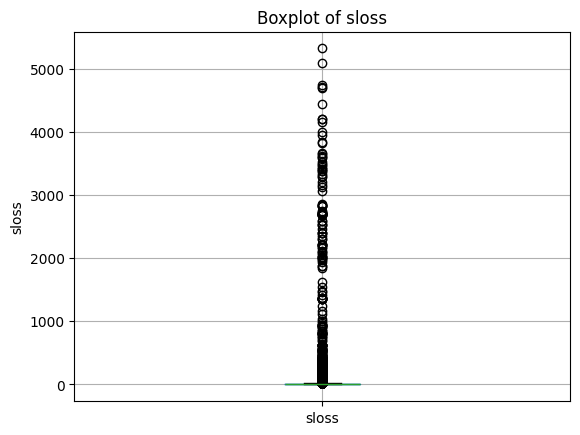

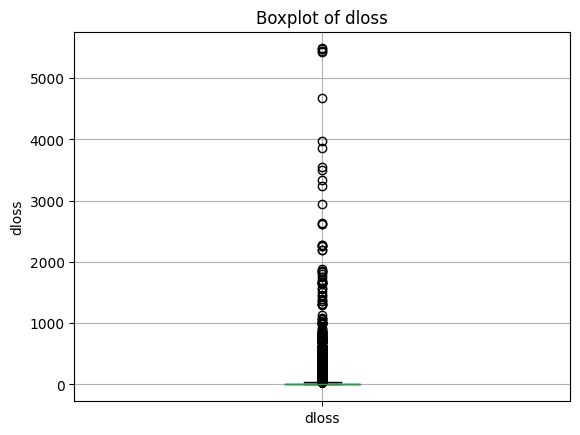

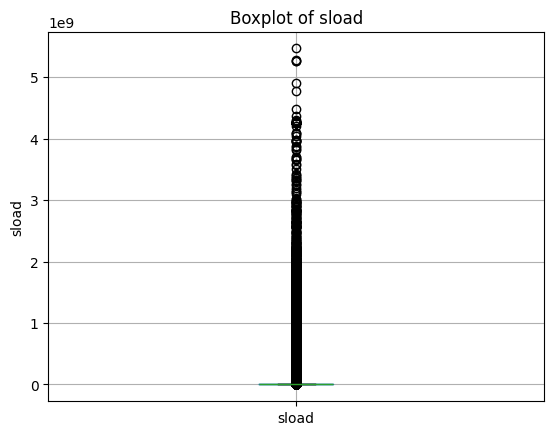

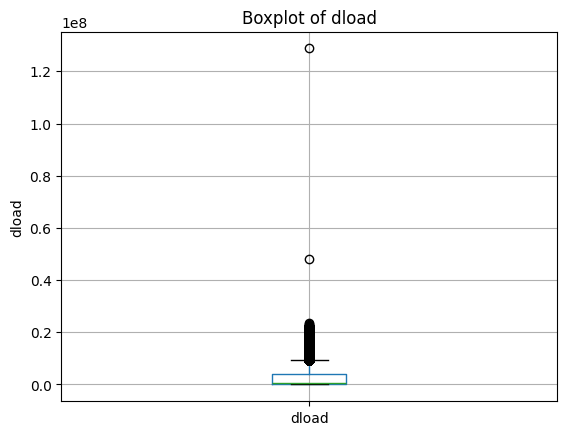

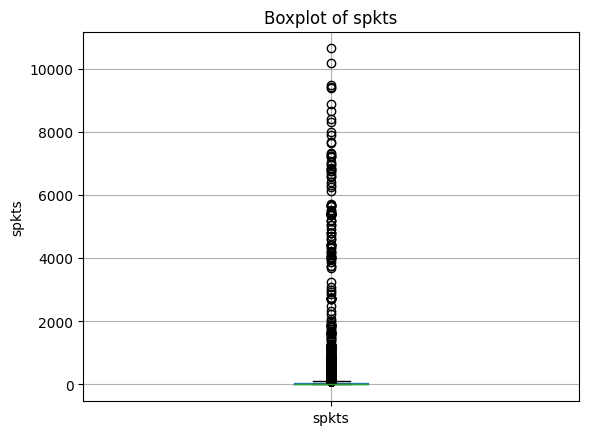

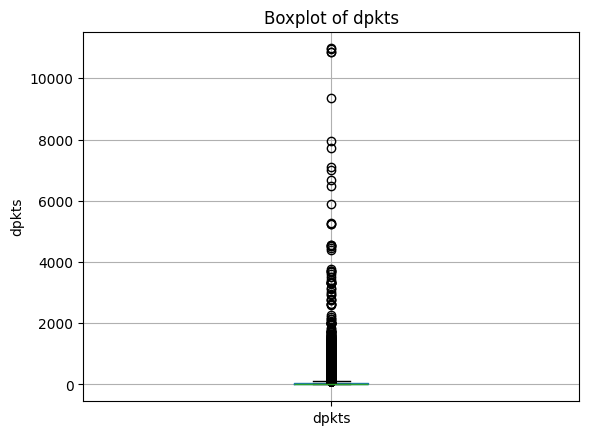

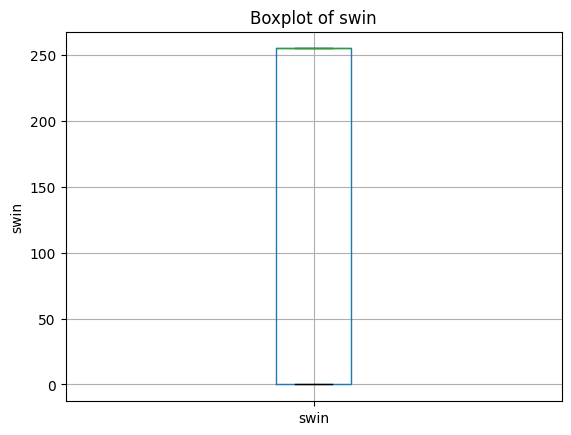

In [39]:
for col in numeric_features_for_plots[:12]:
    train_df_dedup.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

##Compare normal vs attack traffic

In [40]:
grouped_means = train_df_dedup.groupby("label")[numeric_features_for_plots].mean().T

display(grouped_means.head(30))

label,0,1
dur,6.149171e-01,1.324138e+00
sbytes,4.452466e+03,1.746388e+04
dbytes,4.332367e+04,1.360674e+04
sttl,3.486437e+01,2.151892e+02
dttl,3.134527e+01,1.380231e+02
sloss,6.011133e+00,8.007803e+00
dloss,1.955870e+01,6.276012e+00
sload,5.332450e+06,8.223502e+07
dload,3.103434e+06,3.586366e+04
spkts,3.945154e+01,2.234409e+01


In [41]:
grouped_means["absolute_difference"] = (
    grouped_means[1] - grouped_means[0]
).abs()

display(grouped_means.sort_values("absolute_difference", ascending=False).head(20))

label,0,1,absolute_difference
dtcpb,1.524688e+09,1.168090e+09,3.565971e+08
stcpb,1.525297e+09,1.174503e+09,3.507934e+08
sload,5.332450e+06,8.223502e+07,7.690257e+07
dload,3.103434e+06,3.586366e+04,3.067571e+06
ltime,1.423062e+09,1.423910e+09,8.483814e+05
stime,1.423062e+09,1.423910e+09,8.483808e+05
dbytes,4.332367e+04,1.360674e+04,2.971693e+04
sbytes,4.452466e+03,1.746388e+04,1.301142e+04
sjit,1.461426e+03,5.154979e+03,3.693553e+03
res_bdy_len,5.257180e+03,2.551560e+03,2.705620e+03


##Crosstab categorical features vs label

In [42]:
for col in ["proto", "service", "state"]:
    if col in train_df.columns:
        print(f"\nCrosstab: {col} vs label")
        ct = pd.crosstab(train_df_dedup[col], train_df_dedup["label"], normalize="index")
        display(ct.sort_values(by=1, ascending=False).head(20))


Crosstab: proto vs label


label,0,1
proto,,
3pc,0.0,1.0
a/n,0.0,1.0
aes-sp3-d,0.0,1.0
any,0.0,1.0
argus,0.0,1.0
aris,0.0,1.0
ax.25,0.0,1.0
xnet,0.0,1.0
bbn-rcc,0.0,1.0



Crosstab: service vs label


label,0,1
service,,
dhcp,0.000000,1.000000
ssl,0.000000,1.000000
pop3,0.002508,0.997492
snmp,0.010753,0.989247
irc,0.038462,0.961538
radius,0.296296,0.703704
http,0.909924,0.090076
smtp,0.939960,0.060040
dns,0.947124,0.052876



Crosstab: state vs label


label,0,1
state,,
INT,0.412243,0.587757
REQ,0.936982,0.063018
FIN,0.962272,0.037728
ACC,0.964286,0.035714
RST,0.973872,0.026128
CLO,0.992308,0.007692
CON,0.998341,0.001659
ECO,1.000000,0.000000
MAS,1.000000,0.000000


##Correlation analysis

In [43]:
corr_cols = [
    col for col in numeric_features_for_plots
    if col in train_df_dedup.columns
]

spearman_corr = train_df_dedup[corr_cols + ["label"]].corr(method="spearman")

label_corr = spearman_corr["label"].drop("label").sort_values(key=abs, ascending=False)

display(label_corr.head(20))

,label
ct_state_ttl,0.837161
sttl,0.755421
dload,-0.333183
dmeansz,-0.257931
ct_dst_sport_ltm,0.256427
dbytes,-0.210587
dpkts,-0.200251
dloss,-0.155476
spkts,-0.150884
sbytes,-0.137740


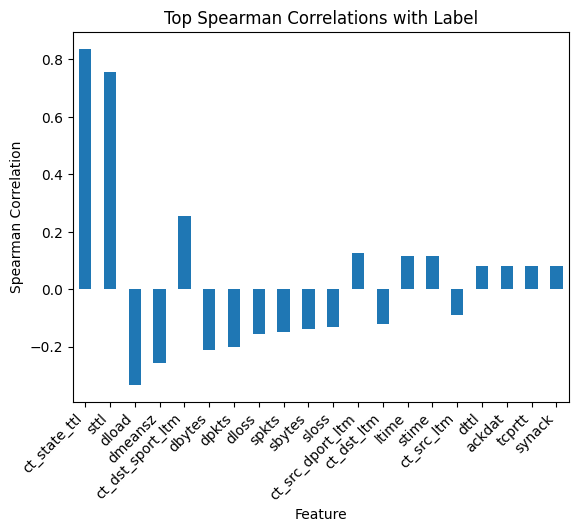

In [44]:
label_corr.head(20).plot(kind="bar")
plt.title("Top Spearman Correlations with Label")
plt.xlabel("Feature")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.show()

In [45]:
corr_matrix = train_df_dedup[corr_cols].corr(method="spearman").abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "abs_spearman_corr"]

display(high_corr_pairs.head(30))

,feature_1,feature_2,abs_spearman_corr
0,stime,ltime,1.000000
1,trans_depth,ct_flw_http_mthd,0.999723
2,swin,dwin,0.996515
3,dloss,dpkts,0.982460
4,spkts,dpkts,0.980784
5,tcprtt,synack,0.972498
6,dloss,spkts,0.966014
7,res_bdy_len,ct_flw_http_mthd,0.948029
8,sintpkt,dintpkt,0.947465
9,trans_depth,res_bdy_len,0.947426


##Temporal Analysis

In [46]:
possible_time_cols = [
    col for col in train_df_dedup.columns
    if "time" in col.lower() or "date" in col.lower() or "stamp" in col.lower()
]

print("Possible temporal columns:", possible_time_cols)

Possible temporal columns: ['stime', 'ltime']


The available preprocessed train/test version does not include explicit timestamp columns, so temporal ordering and time-based drift could not be directly analyzed.

#Feature Engineering

##Defining target and removing leakage columns

In [47]:
from math import nan
target_col = "label"

leakage_or_irrelevant_cols = []

if "attack_cat" in train_df_dedup.columns:
    leakage_or_irrelevant_cols.append("attack_cat")

if "id" in train_df_dedup.columns:
    leakage_or_irrelevant_cols.append("id")

print("Columns removed from features:", leakage_or_irrelevant_cols)

X_train = train_df_dedup.drop(columns=[target_col] + leakage_or_irrelevant_cols)
y_train = train_df_dedup[target_col].astype(int)

X_test = test_df_dedup.drop(columns=[target_col] + leakage_or_irrelevant_cols)
y_test = test_df_dedup[target_col].astype(int)

nan_rows_train = train_df_dedup.isna().any(axis=1)
print(f"Rows with NaN in train: {len(nan_rows_train)}")
nan_rows_test = test_df_dedup.isna().any(axis=1)
print(f"Rows with NaN in test: {len(nan_rows_test)}")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Columns removed from features: ['attack_cat']
Rows with NaN in train: 1647531
Rows with NaN in test: 411883
X_train: (1647531, 47)
X_test: (411883, 47)
y_train: (1647531,)
y_test: (411883,)


In [48]:
print("NaNs in X_train:")
display(X_train.isna().sum()[X_train.isna().sum() > 0])

print("\nNaNs in X_test:")
display(X_test.isna().sum()[X_test.isna().sum() > 0])

NaNs in X_train:


,0



NaNs in X_test:


,0


The column attack_cat was excluded because it represents the attack category and would leak information when predicting the binary label. The id column was excluded because it is an identifier and has no cybersecurity meaning, but there is no such column so there was no need to worry.

##Separating numeric and categorical features

In [49]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["int8","int16","int64", "float64", "int32", "float32"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

print("Number of categorical columns:", len(categorical_cols))
print("Number of numeric columns:", len(numeric_cols))

Categorical columns: ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'service', 'ct_ftp_cmd']
Numeric columns: ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']
Number of categorical columns: 8
Number of numeric columns: 39


##Checking skewed numeric features

In [50]:
skewness = X_train[numeric_cols].skew(numeric_only=True).sort_values(ascending=False)

display(skewness.head(20))
display(skewness.tail(20))

,0
dur,779.841909
trans_depth,158.649881
sbytes,132.419252
sloss,112.762050
djit,79.887927
sjit,57.839304
ackdat,38.017349
synack,37.687385
tcprtt,29.898648
dintpkt,28.033357


,0
dbytes,8.599076
dpkts,8.099530
is_ftp_login,7.677826
ct_dst_src_ltm,6.753718
ct_state_ttl,6.069569
ct_dst_ltm,4.828531
dttl,4.621266
ct_src_ltm,4.016131
sttl,3.885541
smeansz,3.373306


In [51]:
skew_threshold = 1.0

log_transform_cols = [
    col for col in numeric_cols
    if abs(X_train[col].skew()) > skew_threshold and X_train[col].min() >= 0
]

regular_numeric_cols = [
    col for col in numeric_cols
    if col not in log_transform_cols
]

print("Log-transform columns:", log_transform_cols)
print("Regular numeric columns:", regular_numeric_cols)

Log-transform columns: ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'sload', 'dload', 'spkts', 'dpkts', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']
Regular numeric columns: ['swin', 'dwin', 'stcpb', 'dtcpb', 'stime', 'ltime']


A log1p transformation reduces the effect of extreme large values while preserving zero values. This is useful for network traffic features, where unusually large values may dominate distance-based or linear models.

##Build preprocessing pipeline

In [52]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

log_numeric_pipeline = Pipeline(
    steps=[
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler())
    ]
)

regular_numeric_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", log_numeric_pipeline, log_transform_cols),
        ("num", regular_numeric_pipeline, regular_numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ]
)

##Redundency Analysis

In [53]:
corr_matrix = X_train[numeric_cols].corr(method="spearman").abs()
print("The correlation matrix determinant: ",np.linalg.det(corr_matrix))

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "abs_spearman_corr"]

display(high_corr_pairs.head(30))

The correlation matrix determinant:  1.4343425229855945e-34


,feature_1,feature_2,abs_spearman_corr
0,stime,ltime,1.000000
1,trans_depth,ct_flw_http_mthd,0.999723
2,swin,dwin,0.996515
3,dloss,dpkts,0.982460
4,spkts,dpkts,0.980784
5,tcprtt,synack,0.972498
6,dloss,spkts,0.966014
7,res_bdy_len,ct_flw_http_mthd,0.948029
8,sintpkt,dintpkt,0.947465
9,trans_depth,res_bdy_len,0.947426


In [54]:
correlation_threshold = 0.98

features_to_drop_due_to_corr = [
    column for column in upper.columns
    if any(upper[column] > correlation_threshold)
]

print("Highly correlated features to consider dropping:")
print(features_to_drop_due_to_corr)

Highly correlated features to consider dropping:
['dpkts', 'dwin', 'ltime', 'ct_flw_http_mthd']


Several features are highly correlated, suggesting possible redundancy. However, I kept them for the baseline models and later compared this with a reduced-feature version.

#Model Training

##Importing model-training tools

In [55]:
import time
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

##Defining the models

In [56]:
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", LogisticRegression(
                solver="saga",
                max_iter=100,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
                verbose=1
            ))
        ]
    ),

    "Decision Tree": Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", DecisionTreeClassifier(
                max_depth=10,
                min_samples_leaf=9,
                min_samples_split=6,
                class_weight="balanced",
                random_state=42
            ))
        ]
    )
}

Logistic Regression gives a simple interpretable baseline.

Decision Tree can model nonlinear relationships and interactions between network-traffic features.

##Training the models

In [57]:
trained_models = {}
training_times = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()

    trained_models[model_name] = model
    training_times[model_name] = end_time - start_time

    print(f"{model_name} trained in {training_times[model_name]:.2f} seconds\n")

Training Logistic Regression...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 361 seconds
Logistic Regression trained in 375.30 seconds

Training Decision Tree...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Decision Tree trained in 53.35 seconds



##Quick performance check

In [58]:
quick_results = []

for model_name, model in trained_models.items():
    print(f"Evaluating {model_name}...")

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        roc_auc = None

    quick_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "mcc": matthews_corrcoef(y_test, y_pred),
        "roc_auc": roc_auc,
        "training_time_seconds": training_times[model_name]
    })

quick_results_df = pd.DataFrame(quick_results)
display(quick_results_df)

Evaluating Logistic Regression...
Evaluating Decision Tree...


,model,accuracy,precision,recall,f1,mcc,roc_auc,training_time_seconds
0,Logistic Regression,0.985804,0.773246,0.999799,0.872048,0.872670,0.998774,375.295472
1,Decision Tree,0.986261,0.779103,0.999398,0.875607,0.876002,0.996607,53.353539


##Saving the trained models

In [59]:
import joblib
from pathlib import Path

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

for model_name, model in trained_models.items():
    file_name = model_name.lower().replace(" ", "_") + ".joblib"
    joblib.dump(model, models_dir / file_name)

print("Saved models:")
for path in models_dir.glob("*.joblib"):
    print(path)

Saved models:
models/decision_tree.joblib
models/logistic_regression.joblib


#Evaluation

##Defining Evaluation Function

In [60]:
def evaluate_binary_classifier(model_name, model, X_test, y_test):
    """
    Evaluate a binary classifier on the test set.
    Returns a dictionary of metrics and prediction arrays.
    """

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "f2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        "mcc": matthews_corrcoef(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score),
        "average_precision": average_precision_score(y_test, y_score),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
    }

    return metrics, y_pred, y_score

##Evaluating all trained models

In [61]:
evaluation_results = {}
prediction_outputs = {}

for model_name, model in trained_models.items():
    print(f"Evaluating {model_name}...")

    metrics, y_pred, y_score = evaluate_binary_classifier(
        model_name,
        model,
        X_test,
        y_test
    )

    evaluation_results[model_name] = metrics

    prediction_outputs[model_name] = {
        "y_pred": y_pred,
        "y_score": y_score
    }

evaluation_results_df = pd.DataFrame(evaluation_results.values())

display(evaluation_results_df)

Evaluating Logistic Regression...
Evaluating Decision Tree...


,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,average_precision,true_negatives,false_positives,false_negatives,true_positives,false_positive_rate,false_negative_rate
0,Logistic Regression,0.985804,0.992446,0.773246,0.999799,0.872048,0.944456,0.872670,0.998774,0.975903,386111,5843,4,19925,0.014907,0.000201
1,Decision Tree,0.986261,0.992495,0.779103,0.999398,0.875607,0.945906,0.876002,0.996607,0.890237,386307,5647,12,19917,0.014407,0.000602


##Classification Reports

In [62]:
for model_name, model in trained_models.items():
    y_pred = prediction_outputs[model_name]["y_pred"]

    print("=" * 80)
    print(model_name)
    print("=" * 80)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Attack"],
        zero_division=0
    ))

Logistic Regression
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    391954
      Attack       0.77      1.00      0.87     19929

    accuracy                           0.99    411883
   macro avg       0.89      0.99      0.93    411883
weighted avg       0.99      0.99      0.99    411883

Decision Tree
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    391954
      Attack       0.78      1.00      0.88     19929

    accuracy                           0.99    411883
   macro avg       0.89      0.99      0.93    411883
weighted avg       0.99      0.99      0.99    411883



##Confusion matrices

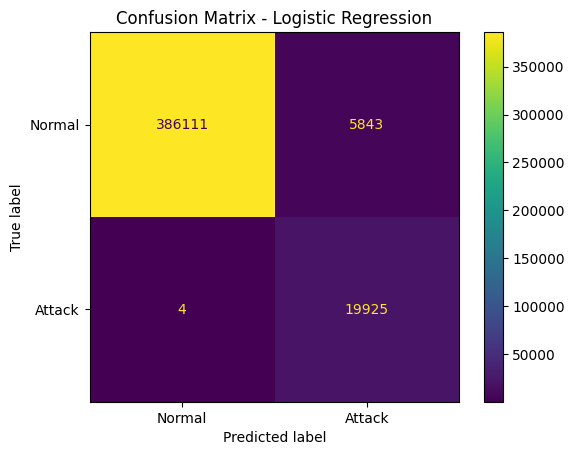

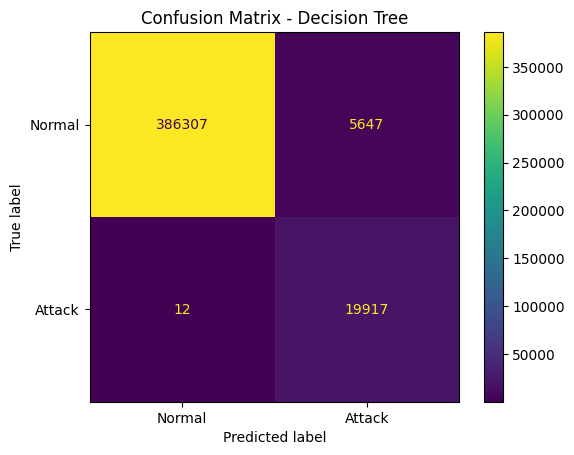

In [63]:
for model_name, model in trained_models.items():
    y_pred = prediction_outputs[model_name]["y_pred"]

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Attack"]
    )

    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

##ROC curves

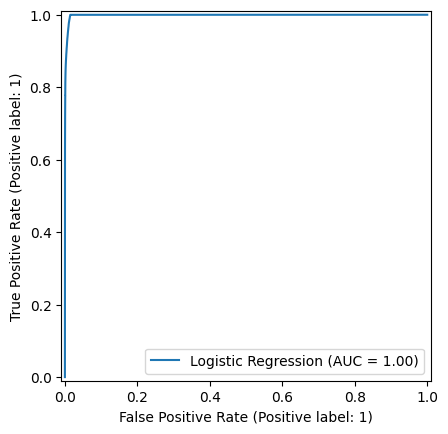

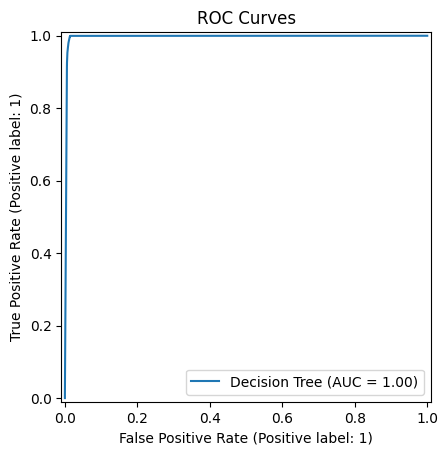

In [64]:
for model_name, model in trained_models.items():
    y_score = prediction_outputs[model_name]["y_score"]

    RocCurveDisplay.from_predictions(
        y_test,
        y_score,
        name=model_name
    )

plt.title("ROC Curves")
plt.show()

##Precision-recall curves

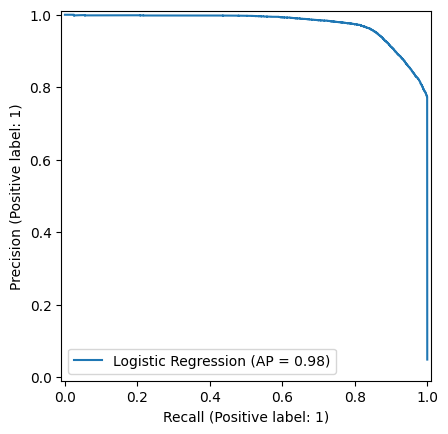

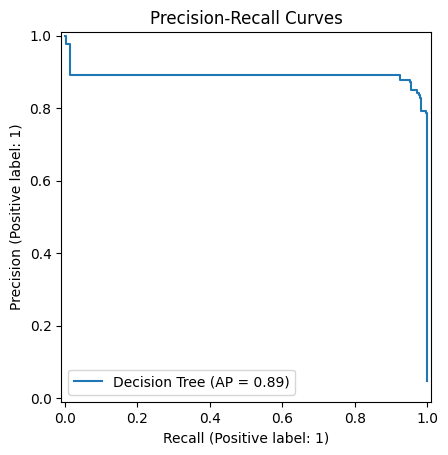

In [65]:
for model_name, model in trained_models.items():
    y_score = prediction_outputs[model_name]["y_score"]

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_score,
        name=model_name
    )

plt.title("Precision-Recall Curves")
plt.show()

##Choosing the best model

In [66]:
evaluation_results_df.sort_values(
    by=["f2", "mcc", "f1"],
    ascending=False
)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,average_precision,true_negatives,false_positives,false_negatives,true_positives,false_positive_rate,false_negative_rate
1,Decision Tree,0.986261,0.992495,0.779103,0.999398,0.875607,0.945906,0.876002,0.996607,0.890237,386307,5647,12,19917,0.014407,0.000602
0,Logistic Regression,0.985804,0.992446,0.773246,0.999799,0.872048,0.944456,0.872670,0.998774,0.975903,386111,5843,4,19925,0.014907,0.000201


In [67]:
best_model_name = evaluation_results_df.sort_values(
    by=["f2", "mcc", "f1"],
    ascending=False
).iloc[0]["model"]

best_model = trained_models[best_model_name]

print("Selected best model:", best_model_name)

Selected best model: Decision Tree


##Evaluation Summary

The models were evaluated using accuracy, balanced accuracy, precision, recall, F1 score, F2 score, MCC, ROC-AUC, average precision, and the confusion matrix.

Accuracy alone is not sufficient for intrusion detection because the cost of false positives and false negatives is asymmetric. A false positive means normal traffic is incorrectly flagged as malicious, which can overload security analysts. A false negative means malicious traffic is classified as normal, which is usually more dangerous because an attack may go undetected.

For this reason, recall, F2 score, MCC, false positive rate, and false negative rate were emphasized in the evaluation.

#Error Analysis

##Building error-analysis dataframe

In [69]:
y_pred_best = prediction_outputs[best_model_name]["y_pred"]
y_score_best = prediction_outputs[best_model_name]["y_score"]

error_df = test_df_dedup.copy()

error_df["y_true"] = y_test.values
error_df["y_pred"] = y_pred_best
error_df["attack_probability"] = y_score_best

def classify_error(row):
    if row["y_true"] == 0 and row["y_pred"] == 0:
        return "True Negative"
    elif row["y_true"] == 0 and row["y_pred"] == 1:
        return "False Positive"
    elif row["y_true"] == 1 and row["y_pred"] == 0:
        return "False Negative"
    elif row["y_true"] == 1 and row["y_pred"] == 1:
        return "True Positive"

error_df["prediction_type"] = error_df.apply(classify_error, axis=1)

display(error_df[["y_true", "y_pred", "attack_probability", "prediction_type"]].head())

,y_true,y_pred,attack_probability,prediction_type
0,0,0,0.0,True Negative
1,0,0,0.0,True Negative
2,0,0,0.0,True Negative
3,0,0,0.0,True Negative
4,0,0,0.0,True Negative


##Count prediction types

,count
prediction_type,
True Negative,386307
True Positive,19917
False Positive,5647
False Negative,12


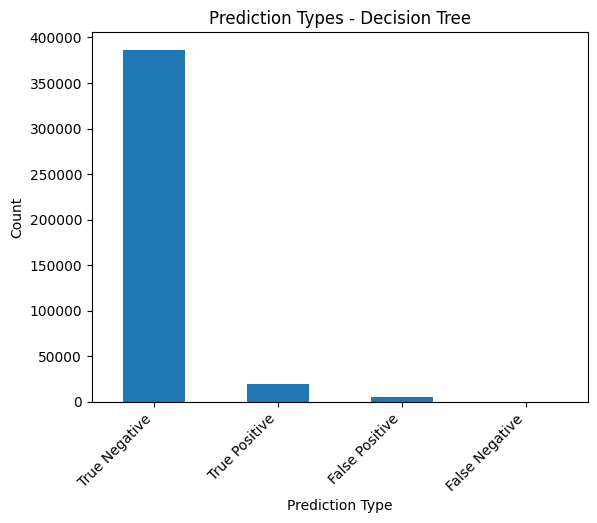

In [70]:
error_counts = error_df["prediction_type"].value_counts()
display(error_counts)

error_counts.plot(kind="bar")
plt.title(f"Prediction Types - {best_model_name}")
plt.xlabel("Prediction Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

##Analysing False Positives

In [71]:
false_positives = error_df[error_df["prediction_type"] == "False Positive"]

print("Number of false positives:", len(false_positives))
display(false_positives.head())

Number of false positives: 5647


,srcip,sport,dstip,dsport,proto,...,label,y_true,y_pred,attack_probability,prediction_type
131,175.45.176.1,60494,149.171.126.12,179,tcp,...,0,0,1,0.905099,False Positive
507,175.45.176.3,65420,149.171.126.18,179,tcp,...,0,0,1,0.910191,False Positive
671,175.45.176.2,59656,149.171.126.15,1723,tcp,...,0,0,1,0.993864,False Positive
743,175.45.176.1,1509,149.171.126.12,1723,tcp,...,0,0,1,0.993864,False Positive
759,175.45.176.0,38338,149.171.126.12,179,tcp,...,0,0,1,0.817277,False Positive


In [72]:
display(
    false_positives.sort_values(
        by="attack_probability",
        ascending=False
    ).head(20)
)

,srcip,sport,dstip,dsport,proto,...,label,y_true,y_pred,attack_probability,prediction_type
402324,175.45.176.3,62268,149.171.126.10,179,tcp,...,0,0,1,0.999160,False Positive
184096,175.45.176.1,5060,149.171.126.12,4569,udp,...,0,0,1,0.999076,False Positive
191372,175.45.176.2,25194,149.171.126.19,80,tcp,...,0,0,1,0.999076,False Positive
239999,175.45.176.0,31888,149.171.126.18,21554,tcp,...,0,0,1,0.999076,False Positive
248661,175.45.176.0,5060,149.171.126.13,4569,udp,...,0,0,1,0.999076,False Positive
279559,175.45.176.3,2746,149.171.126.19,80,tcp,...,0,0,1,0.999076,False Positive
66130,175.45.176.1,55611,149.171.126.11,179,tcp,...,0,0,1,0.996248,False Positive
106895,175.45.176.3,45373,149.171.126.19,135,tcp,...,0,0,1,0.993864,False Positive
107075,175.45.176.3,53211,149.171.126.13,135,tcp,...,0,0,1,0.993864,False Positive
107085,175.45.176.2,24498,149.171.126.10,21,tcp,...,0,0,1,0.993864,False Positive


The model seems to classify normal traffic as attack traffic with high certainty.

##Analysing False Negatives

In [73]:
false_negatives = error_df[error_df["prediction_type"] == "False Negative"]

print("Number of false negatives:", len(false_negatives))
display(false_negatives.head())

Number of false negatives: 12


,srcip,sport,dstip,dsport,proto,...,label,y_true,y_pred,attack_probability,prediction_type
23728,175.45.176.3,40767,149.171.126.11,520,udp,...,1,1,0,0.483624,False Negative
71226,175.45.176.3,39394,149.171.126.12,80,tcp,...,1,1,0,0.380661,False Negative
75342,175.45.176.1,47526,149.171.126.19,179,tcp,...,1,1,0,0.000000,False Negative
78896,175.45.176.2,28942,149.171.126.10,179,tcp,...,1,1,0,0.000000,False Negative
101541,175.45.176.1,53371,149.171.126.19,179,tcp,...,1,1,0,0.000000,False Negative


In [74]:
display(
    false_negatives.sort_values(
        by="attack_probability",
        ascending=True
    ).head(20)
)

,srcip,sport,dstip,dsport,proto,...,label,y_true,y_pred,attack_probability,prediction_type
78896,175.45.176.2,28942,149.171.126.10,179,tcp,...,1,1,0,0.000000,False Negative
75342,175.45.176.1,47526,149.171.126.19,179,tcp,...,1,1,0,0.000000,False Negative
121238,175.45.176.2,50513,149.171.126.10,179,tcp,...,1,1,0,0.000000,False Negative
101541,175.45.176.1,53371,149.171.126.19,179,tcp,...,1,1,0,0.000000,False Negative
340714,175.45.176.2,18047,149.171.126.13,179,tcp,...,1,1,0,0.000000,False Negative
402589,175.45.176.1,47679,149.171.126.19,179,tcp,...,1,1,0,0.000000,False Negative
278312,175.45.176.1,62718,149.171.126.13,520,udp,...,1,1,0,0.000000,False Negative
211058,175.45.176.2,1888,149.171.126.12,520,udp,...,1,1,0,0.103697,False Negative
71226,175.45.176.3,39394,149.171.126.12,80,tcp,...,1,1,0,0.380661,False Negative
305118,175.45.176.3,39394,149.171.126.12,80,tcp,...,1,1,0,0.380661,False Negative


The model also seems to classify attack traffic as normal traffic with high certainty but it is not as certain as the False Positive case which is good, we want it to be careful with letting attacks pass by.

##Error analysis by attack category

In [75]:
if "attack_cat" in error_df.columns:
    attack_error_table = pd.crosstab(
        error_df["attack_cat"],
        error_df["prediction_type"],
        margins=True
    )

    display(attack_error_table)

prediction_type,False Negative,False Positive,True Negative,True Positive,All
attack_cat,,,,,
Analysis,0,0,0,455,455
Backdoor,0,0,0,371,371
Backdoors,0,0,0,69,69
DoS,0,0,0,1114,1114
Exploits,0,0,0,5486,5486
Fuzzers,10,0,0,4342,4352
Generic,0,0,0,5118,5118
Normal,0,5647,386307,0,391954
Reconnaissance,2,0,0,2616,2618


In [76]:
if "attack_cat" in error_df.columns:
    attack_category_summary = (
        error_df[error_df["y_true"] == 1]
        .groupby("attack_cat")
        .agg(
            total_attacks=("y_true", "size"),
            missed_attacks=("prediction_type", lambda x: (x == "False Negative").sum())
        )
    )

    attack_category_summary["false_negative_rate"] = (
        attack_category_summary["missed_attacks"] /
        attack_category_summary["total_attacks"]
    )

    display(
        attack_category_summary.sort_values(
            by="false_negative_rate",
            ascending=False
        )
    )

,total_attacks,missed_attacks,false_negative_rate
attack_cat,,,
Fuzzers,4352,10,0.002298
Reconnaissance,2618,2,0.000764
Backdoor,371,0,0.000000
Analysis,455,0,0.000000
DoS,1114,0,0.000000
Backdoors,69,0,0.000000
Exploits,5486,0,0.000000
Generic,5118,0,0.000000
Shellcode,310,0,0.000000


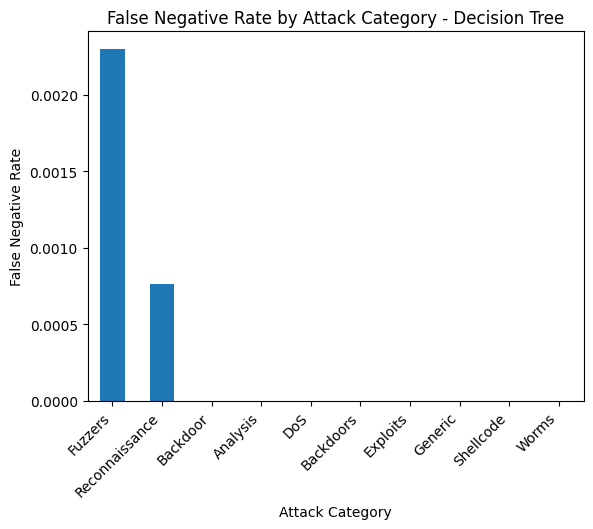

In [77]:
if "attack_cat" in error_df.columns:
    attack_category_summary.sort_values(
        by="false_negative_rate",
        ascending=False
    )["false_negative_rate"].plot(kind="bar")

    plt.title(f"False Negative Rate by Attack Category - {best_model_name}")
    plt.xlabel("Attack Category")
    plt.ylabel("False Negative Rate")
    plt.xticks(rotation=45, ha="right")
    plt.show()

It seems like most of the false negative cases fail to indentify the Fuzzers attack. It is a pattern I have noticed not just in this current configuration. This could be because of the nature of the attack since it is attacking the system by sending invalid, random or edge case inputs in order to find usable exploits.

##Error analysis by categorical network features

In [78]:
for col in ["proto", "service", "state"]:
    if col in error_df.columns:
        print(f"\nError distribution by {col}")

        table = pd.crosstab(
            error_df[col],
            error_df["prediction_type"],
            normalize="index"
        )

        display(
            table.sort_values(
                by="False Negative" if "False Negative" in table.columns else table.columns[0],
                ascending=False
            ).head(20)
        )


Error distribution by proto


prediction_type,False Negative,False Positive,True Negative,True Positive
proto,,,,
udp,0.000034,0.010929,0.93256,0.056476
tcp,0.000028,0.015038,0.94792,0.037015
aes-sp3-d,0.000000,0.000000,0.00000,1.000000
any,0.000000,0.000000,0.00000,1.000000
3pc,0.000000,0.000000,0.00000,1.000000
a/n,0.000000,0.000000,0.00000,1.000000
aris,0.000000,0.000000,0.00000,1.000000
argus,0.000000,0.000000,0.00000,1.000000
arp,0.000000,0.000000,1.00000,0.000000



Error distribution by service


prediction_type,False Negative,False Positive,True Negative,True Positive
service,,,,
-,0.000047,0.020619,0.935655,0.043679
http,0.000024,0.016190,0.894424,0.089362
dhcp,0.000000,0.000000,0.000000,1.000000
ftp,0.000000,0.017409,0.938299,0.044293
dns,0.000000,0.000039,0.946945,0.053017
ftp-data,0.000000,0.000201,0.991960,0.007839
irc,0.000000,0.000000,0.000000,1.000000
pop3,0.000000,0.003401,0.000000,0.996599
radius,0.000000,0.000000,0.200000,0.800000



Error distribution by state


prediction_type,False Negative,False Positive,True Negative,True Positive
state,,,,
RST,0.019231,0.028846,0.951923,0.000000
REQ,0.000816,0.002447,0.938825,0.057912
INT,0.000199,0.084957,0.319814,0.595030
FIN,0.000021,0.015160,0.947526,0.037293
CLO,0.000000,0.033333,0.966667,0.000000
CON,0.000000,0.000101,0.998306,0.001593
ACC,0.000000,0.000000,0.923077,0.076923
ECO,0.000000,0.000000,1.000000,0.000000
ECR,0.000000,0.000000,1.000000,0.000000


##Compare feature values for correct vs incorrect predictions

In [79]:
numeric_cols_for_error = error_df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

cols_to_exclude = ["id", "label", "y_true", "y_pred", "attack_probability"]
numeric_cols_for_error = [
    col for col in numeric_cols_for_error
    if col not in cols_to_exclude
]

error_group_summary = error_df.groupby("prediction_type")[numeric_cols_for_error].mean().T

display(error_group_summary.head(30))

prediction_type,False Negative,False Positive,True Negative,True Positive
dur,5.638376e-01,9.540555e-01,6.169526e-01,1.374519e+00
sbytes,1.167308e+04,5.141523e+03,4.470337e+03,1.858420e+04
dbytes,2.461667e+02,9.298491e+02,4.411989e+04,1.436439e+04
sttl,2.540000e+02,2.305686e+02,3.203096e+01,2.152434e+02
dttl,1.360000e+02,1.943432e+02,2.901649e+01,1.364055e+02
sloss,5.250000e+00,3.404285e+00,6.066696e+00,8.309083e+00
dloss,8.333333e-01,1.482380e+00,1.989066e+01,6.550485e+00
sload,8.494007e+07,9.330172e+07,3.993770e+06,8.463862e+07
dload,2.209331e+03,4.290913e+03,3.144976e+06,3.465751e+04
spkts,1.500000e+01,1.198495e+01,3.993692e+01,2.300226e+01


In [80]:
if "True Positive" in error_group_summary.columns and "False Negative" in error_group_summary.columns:
    fn_vs_tp = error_group_summary[["True Positive", "False Negative"]].copy()

    fn_vs_tp["absolute_difference"] = (
        fn_vs_tp["True Positive"] - fn_vs_tp["False Negative"]
    ).abs()

    display(
        fn_vs_tp.sort_values(
            by="absolute_difference",
            ascending=False
        ).head(20)
    )

prediction_type,True Positive,False Negative,absolute_difference
dtcpb,1.170814e+09,1.779795e+09,6.089809e+08
stcpb,1.153846e+09,1.178026e+09,2.417938e+07
sload,8.463862e+07,8.494007e+07,3.014546e+05
ltime,1.423912e+09,1.423865e+09,4.678004e+04
stime,1.423912e+09,1.423865e+09,4.677941e+04
dload,3.465751e+04,2.209331e+03,3.244818e+04
dbytes,1.436439e+04,2.461667e+02,1.411822e+04
sbytes,1.858420e+04,1.167308e+04,6.911116e+03
res_bdy_len,3.021966e+03,0.000000e+00,3.021966e+03
sintpkt,9.824411e+01,1.842032e+03,1.743788e+03


##Threshold analysis

In [81]:
thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_score_best >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
        "f2": fbeta_score(y_test, y_pred_threshold, beta=2, zero_division=0),
        "mcc": matthews_corrcoef(y_test, y_pred_threshold),
        "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        "false_positives": fp,
        "false_negatives": fn
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df)

,threshold,precision,recall,f1,f2,mcc,false_positive_rate,false_negative_rate,false_positives,false_negatives
0,0.10,0.775718,0.999649,0.873561,0.945084,0.874087,0.014696,0.000351,5760,7
1,0.15,0.776496,0.999599,0.874035,0.945279,0.874531,0.014629,0.000401,5734,8
2,0.20,0.776496,0.999599,0.874035,0.945279,0.874531,0.014629,0.000401,5734,8
3,0.25,0.776496,0.999599,0.874035,0.945279,0.874531,0.014629,0.000401,5734,8
4,0.30,0.776496,0.999599,0.874035,0.945279,0.874531,0.014629,0.000401,5734,8
5,0.35,0.776496,0.999599,0.874035,0.945279,0.874531,0.014629,0.000401,5734,8
6,0.40,0.778420,0.999498,0.875214,0.945777,0.875639,0.014466,0.000502,5670,10
7,0.45,0.778420,0.999498,0.875214,0.945777,0.875639,0.014466,0.000502,5670,10
8,0.50,0.779103,0.999398,0.875607,0.945906,0.876002,0.014407,0.000602,5647,12
9,0.55,0.779443,0.999247,0.875764,0.945898,0.876135,0.014377,0.000753,5635,15


##Error Analysis Summary

Error analysis was performed by separating predictions into true positives, true negatives, false positives, and false negatives. False positives represent normal traffic that would generate unnecessary IDS alerts. False negatives represent attack traffic that would bypass the IDS, making them particularly important in cybersecurity.

The analysis also examined whether errors were concentrated in specific attack categories, protocols, services, or connection states. This is important because high overall binary classification performance can hide poor detection of rare or difficult attack categories.

A threshold analysis was also performed to study the trade-off between detecting more attacks and reducing false alarms.

#Executive Summary

This project critically evaluates and reproduces the blog post “Building an Intrusion Detection System on UNSW-NB15 Dataset Based on Machine Learning Algorithm” by Subrata Maji. The source presents a machine-learning pipeline for building a binary Intrusion Detection System (IDS), where each network traffic record is classified as either normal traffic or attack traffic.

The dataset used in this project is UNSW-NB15, a benchmark cybersecurity dataset containing normal traffic and several categories of network attacks. The full dataset contains network-flow features such as protocol, service, connection state, packet counts, byte counts, duration-related features, and attack labels. These features make the dataset suitable for supervised intrusion detection experiments.

The original source proposes a standard data-science workflow: loading and cleaning the data, performing exploratory data analysis, engineering features, training multiple machine-learning models, and comparing their performance. In my reproduction, I followed the same general methodology using the full UNSW-NB15 CSV dataset. This was important because an earlier smaller train-test version of the dataset produced a different setup, while the full dataset matched the blog’s description more closely and produced results closer to the original reported behavior.

The main task was binary classification using the label column, where 0 represents normal traffic and 1 represents attack traffic. The attack_cat column was not used as an input feature because it directly describes the attack type and would cause target leakage. The id column was also removed because it is an artificial identifier rather than a meaningful network-behavior feature.

The feature-engineering process included handling categorical and numerical features separately. Categorical features such as proto, service, and state were encoded using one-hot encoding. Numerical features were standardized where appropriate, and skewed non-negative numerical features were considered for logarithmic transformation. These preprocessing steps were implemented using a machine-learning pipeline to reduce the risk of inconsistent preprocessing and data leakage.

Several classification models were trained and evaluated, including Logistic Regression, Decision Tree, and Random Forest. Logistic Regression served as a simple linear baseline, while Decision Tree and Random Forest represented tree-based models that can capture nonlinear relationships and feature interactions. The models were evaluated using accuracy, precision, recall, F1 score, F2 score, Matthews Correlation Coefficient, ROC-AUC, false positive rate, false negative rate, and confusion matrices.

The results support the author’s main claim that machine-learning models can detect attacks in the UNSW-NB15 dataset. In particular, the tree-based models achieved strong performance and produced results close to those reported in the original blog. The Decision Tree achieved very high recall, meaning that it detected almost all attack samples. This is important in an IDS context because false negatives represent attacks that pass undetected.

However, the results should still be interpreted carefully. Strong binary classification performance on UNSW-NB15 does not automatically prove that the model is suitable for real-world intrusion detection. Real network environments can change over time, and new attacks may differ from the patterns in the dataset. In addition, binary classification can hide weaknesses across specific attack categories. A model may perform well overall while still missing rare or difficult attacks.

Overall, the project confirms that the author’s methodology is useful as an educational machine-learning IDS pipeline. The results support the use of supervised learning for binary intrusion detection on UNSW-NB15. At the same time, a stronger evaluation would require attack-category-level error analysis, temporal validation, testing on additional datasets, and a deeper discussion of false positives and false negatives in real security operations.

#Summing It Up

This project examined whether the machine-learning IDS approach presented in the selected blog post is supported by reproducible experiments and meaningful evaluation. The selected source was Subrata Maji’s blog post and GitHub repository on building an Intrusion Detection System using the UNSW-NB15 dataset.

The problem addressed by the source is binary network intrusion detection. Each network traffic record must be classified as either normal or malicious. This is an important cybersecurity problem because organizations need to detect attacks while avoiding excessive false alarms.

The dataset used was UNSW-NB15, a standard benchmark dataset for intrusion detection. It contains normal traffic, multiple attack categories, and numerical and categorical network-flow features. In this project, I used the full four-file CSV version of the dataset because it more closely matched the original blog’s description and produced results closer to the author’s reported results.

The methodology followed a supervised machine-learning pipeline. First, the data was loaded and inspected. Then exploratory data analysis was performed to understand label distribution, attack categories, feature types, missing values, outliers, correlations, and possible redundancy. Feature engineering was then applied to remove leakage columns, encode categorical features, scale numerical features, and prepare the data for model training.

The main models trained were Logistic Regression, Decision Tree, and Random Forest. Logistic Regression was used as a simple baseline, while the tree-based models were used because the original source emphasized their strong performance. The models were evaluated using multiple metrics, including accuracy, precision, recall, F1, F2, MCC, ROC-AUC, false positive rate, false negative rate, and confusion matrices.

The reproduction results were close to the original blog’s results after switching to the full dataset. This supports the author’s main claim that machine-learning models can distinguish between normal and attack traffic in UNSW-NB15. The tree-based models performed especially well, and the Decision Tree achieved very high recall, which is valuable in intrusion detection because missed attacks are usually more dangerous than extra alerts.

At the same time, the project shows that high performance on this dataset should not be interpreted as proof of real-world IDS reliability. The original source mainly focuses on binary classification metrics, but real cybersecurity systems also require analysis by attack category, time-based generalization, and operational error costs. False negatives can allow attacks to pass undetected, while false positives can overload analysts with unnecessary alerts.

The most important insight from the reproduction is that dataset version matters. When using a smaller processed train-test version, the setup differed from the original blog. When using the full CSV dataset, the experiment became much closer to the source and produced more comparable results. This highlights the importance of precise dataset documentation in reproducible cybersecurity research.

In conclusion, I recommend the selected project as a useful educational example of applying machine learning to intrusion detection. The author’s main conclusion is mostly justified within the UNSW-NB15 dataset. However, I would not treat the resulting model as a complete real-world IDS without further validation. Future improvements should include attack-category-level evaluation, temporal testing, additional datasets, stronger error analysis, and clearer documentation of preprocessing and feature-selection steps.

#<font color="red">Changes After Review

After receiving feedback, I added an explicit duplicate-row analysis. I checked how many exact duplicate rows existed in the concatenated raw dataset and measured direct train-test duplicate overlap after a random split. Because duplicate overlap can lead to overly optimistic results, I repeated the main experiment after removing exact duplicate rows before splitting.

I also updated the notebook and report to clarify that the executed reproduction includes Logistic Regression and Decision Tree only. Random Forest is discussed in the original blog, but it was not included in my executed reproduction, so unsupported Random Forest claims were removed from my results and conclusions.

Finally, I updated the interpretation of the results to clarify that strong performance on a random split of UNSW-NB15 does not prove reliable detection on future traffic, unseen hosts, or another network.